# Storm climatology over Indonesia

Reads the multi-year catalogue built by `src/build_year.py` and produces the
climatology: seasonal cycle, regions, severity, families, the diurnal cycle and
sea-to-land transitions.

Notebook 01 builds storms from rainfall. This one asks what 13 million of them
say. It needs the catalogue to exist:

```
python src\build_year.py --year 1998 2025 --prominence 4
```

About 9 hours, resumable. Every number below is numbered in
[docs/findings.md](../docs/findings.md) with the command that produced it.

## 1. Load

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from climatology import load, record_years
from config import DATA_PROCESSED
import severity

pd.set_option("display.width", 190)
plt.rcParams["figure.dpi"] = 110

COLS = ["year", "month", "start_time", "duration_h", "total_volume_km3",
        "max_intensity_mm_hr", "max_area_km2", "wcentroid_lat",
        "wcentroid_lon", "truncated_time", "truncated_space"]
df = load(cols=COLS)
yrs = record_years(df)          # months present / 12, not calendar years
clean = df[~(df.truncated_time | df.truncated_space)]
print(f"{len(df):,} storms, {yrs:.2f} yr, "
      f"{df.total_volume_km3.sum():,.0f} km3")
print(f"untruncated {len(clean):,} ({100*len(clean)/len(df):.1f}%)")

13,386,185 storms, 27.75 yr, 618,505 km3
untruncated 12,453,713 (93.0%)


`record_years` counts **months actually present**, not calendar years. 2025 is a
nine-month year because IMERG Final ends 2025-09-30, and counting it as a full
year would deflate every rate and return period.

## 2. Seasonal cycle

One year cannot rank the months. In 2020 alone January came 9th of 12; over 28
years it is the **second wettest**.

wettest 12 (0.111), driest 8 (0.060), ratio 1.87x


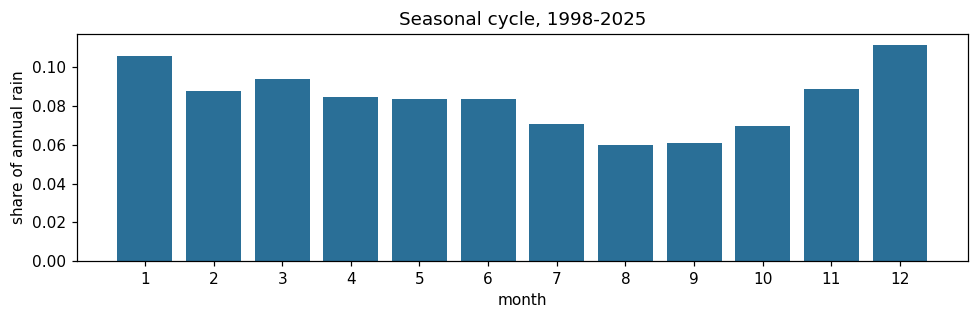

In [2]:
m = df.groupby("month").agg(storms=("duration_h", "size"),
                            vol=("total_volume_km3", "sum"))
m["share"] = m.vol / m.vol.sum()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(m.index, m.share, color="#2a6f97")
ax.set_xticks(range(1, 13)); ax.set_xlabel("month")
ax.set_ylabel("share of annual rain")
ax.set_title(f"Seasonal cycle, {df.year.min()}-{df.year.max()}")
fig.tight_layout()
print(f"wettest {m.share.idxmax()} ({m.share.max():.3f}), "
      f"driest {m.share.idxmin()} ({m.share.min():.3f}), "
      f"ratio {m.share.max()/m.share.min():.2f}x")

## 3. Interannual variability

1,341 to 2,211 km3 (1.65x), min 2015, max 2010


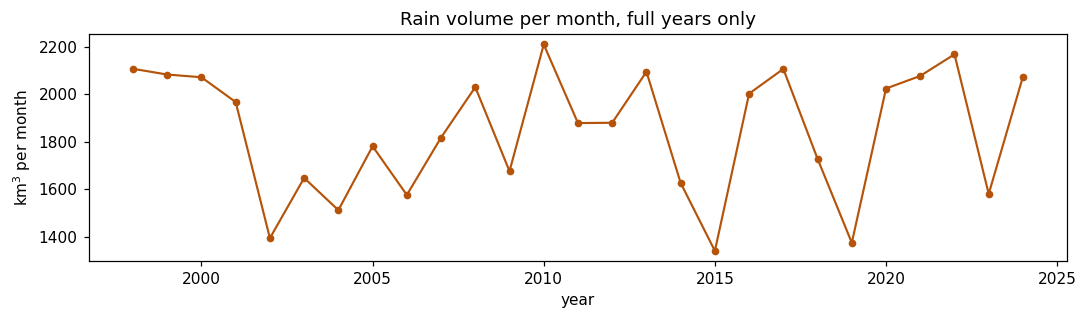

In [3]:
g = df.groupby("year").agg(storms=("duration_h", "size"),
                           vol=("total_volume_km3", "sum"),
                           months=("month", "nunique"))
g["vol_per_month"] = g.vol / g.months
full = g[g.months == 12]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(full.index, full.vol_per_month, "o-", color="#b45309", lw=1.4, ms=4)
ax.set_ylabel("km$^3$ per month"); ax.set_xlabel("year")
ax.set_title("Rain volume per month, full years only")
fig.tight_layout()
print(f"{full.vol_per_month.min():,.0f} to {full.vol_per_month.max():,.0f} km3 "
      f"({full.vol_per_month.max()/full.vol_per_month.min():.2f}x), "
      f"min {full.vol_per_month.idxmin()}, max {full.vol_per_month.idxmax()}")

2015 and 2010 are the extremes, which are a strong El Nino and a strong La Nina
respectively. That is the expected sign for the maritime continent, but **no ENSO
index has been correlated here**, so treat the pairing as an observation rather
than a result.

## 4. Regions

Derived from the catalogue itself: storm volume binned onto a 1 degree grid by
month, each cell's 12-month cycle normalised, then clustered on that **shape**.
The clustering never sees how much a cell rains or where it is, so the spatial
coherence of the result is a check on the method rather than an input.

```
python src\regions.py --grid 1.0 --kmax 6 --k 3
```

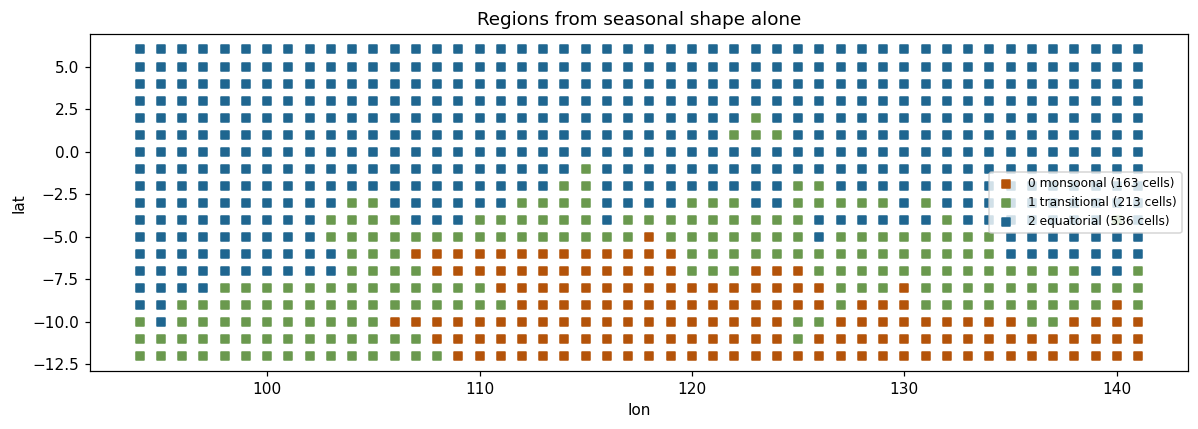

In [4]:
REG = DATA_PROCESSED / "regions_k3.parquet"
if not REG.exists():
    print(f"run:  python src\\regions.py --grid 1.0 --kmax 6 --k 3")
else:
    reg = pd.read_parquet(REG)
    NAMES = {0: "monsoonal", 1: "transitional", 2: "equatorial"}
    fig, ax = plt.subplots(figsize=(11, 4))
    for r, c in zip(sorted(reg.region.unique()), ["#b45309", "#6a994e", "#1f6690"]):
        s = reg[reg.region == r]
        ax.scatter(s.glon, s.glat, s=28, marker="s", c=c,
                   label=f"{r} {NAMES.get(r, r)} ({len(s)} cells)")
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.legend(fontsize=8)
    ax.set_title("Regions from seasonal shape alone")
    fig.tight_layout()

The monsoonal region varies **54.5-fold** between January and August. Domain-wide
the figure is 1.87x, because the equatorial region is 69% of the volume and nearly
aseasonal. Aggregating understates the country's strongest seasonal signal by about
29x, which is why the severity scale below has to be regional.

## 5. Severity

Bands are **exceedance rates** (storms per year), not percentiles and not return
periods. With ~449,000 storms a year, p99 is exceeded about 4,500 times a year, so
percentile bands would leave the upper classes empty; and a 1-in-1-year storm is
just the 28th largest in a 28-year record.

In [5]:
sc = severity.fit(clean, n_years=yrs)
print(sc.describe())

cls = sc.classify(clean.total_volume_km3.values,
                  clean.max_intensity_mm_hr.values)
t = (cls.groupby(["severity_index", "severity"]).size()
        .reset_index(name="n"))
t["per_year"] = t.n / yrs
t["share"] = t.n / len(cls)
t.round(5)

SeverityScale[all] n=12,453,713 storms over 27.8 yr, basis=return_period, honest to T<=28 yr
  bands by exceedance rate (T = 1/rate)
  volume     >=500/yr at 1.1502 km3, >=50/yr at 2.1747 km3
  intensity  >=500/yr at 71.4 mm/hr, >=50/yr at 96.6 mm/hr


,severity_index,severity,n,per_year,share
0,0,very low,12426479,447801.04505,0.99781
1,1,low,12022,433.22523,0.00097
2,2,moderate,1337,48.18018,0.00011
3,3,medium,12081,435.35135,0.00097
4,4,heavy,366,13.18919,0.00003
5,5,very heavy,40,1.44144,0.00000
6,6,intense,1273,45.87387,0.00010
7,7,severe,104,3.74775,0.00001
8,8,extreme,11,0.39640,0.00000


Nearly all storms sit in the lowest class, and that is not a fault of the bands:
at this granularity the scale usefully ranks the notable tail, roughly the top
thousand storms a year. It does not describe the whole population.

### Why the scale has to be regional

In [6]:
# Self-contained: re-reads the regions rather than relying on names defined in
# an earlier cell's else-branch, so this still works after a kernel restart.
if not REG.exists():
    print("run:  python src/regions.py --grid 1.0 --kmax 6 --k 3")
else:
    reg = pd.read_parquet(REG)
    NAMES = {0: "monsoonal", 1: "transitional", 2: "equatorial"}
    d = clean.dropna(subset=["wcentroid_lat", "wcentroid_lon"]).copy()
    d["glat"] = np.floor(d.wcentroid_lat); d["glon"] = np.floor(d.wcentroid_lon)
    d = d.merge(reg[["glat", "glon", "region"]], on=["glat", "glon"])
    dom = severity.fit(d, n_years=yrs)
    rows = []
    for r, gg in d.groupby("region"):
        cd = dom.classify(gg.total_volume_km3.values,
                          gg.max_intensity_mm_hr.values)
        rows.append({"region": NAMES.get(r, r), "storms": len(gg),
                     "notable_per_year": int((cd.severity_index >= 6).sum()) / yrs})
    out = pd.DataFrame(rows)
    out["bias_vs_equatorial"] = out.notable_per_year.max() / out.notable_per_year
    print(out.round(2).to_string(index=False))
    print()
    print("Under ONE domain-wide scale the monsoonal region looks quiet purely")
    print("because the equatorial region dominates the tail.")

      region  storms  notable_per_year  bias_vs_equatorial
   monsoonal 1358198              3.57                9.46
transitional 2755264             12.68                2.66
  equatorial 8340251             33.77                1.00

Under ONE domain-wide scale the monsoonal region looks quiet purely
because the equatorial region dominates the tail.


## 6. Rainfall concentration

The AGU 2020 poster reported that long-lived storms were 13% of the Lower Mekong
population and carried more than 97% of monsoon rainfall. Here the top 13% by
volume carry about 71%.

That gap is largely **partition granularity**: at h=4 we resolve roughly 14x more
storms per unit area than that study did, and concentration depends directly on how
finely the field is cut. Matching their storm density reproduces much of their
figure.

In [7]:
curve, inv = severity.contribution_curve(clean)
print(curve.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
for share, frac in inv.items():
    print(f"  {share:.0%} of the rain comes from the top {100*frac:5.2f}% of storms")

 top_frac  n_storms  volume_share
   0.0100    124537        0.1843
   0.0500    622686        0.4634
   0.1000   1245371        0.6373
   0.1300   1618983        0.7065
   0.2000   2490743        0.8159
   0.5000   6226856        0.9729

  50% of the rain comes from the top  5.83% of storms
  90% of the rain comes from the top 29.52% of storms
  97% of the rain comes from the top 48.38% of storms
  99% of the rain comes from the top 65.79% of storms


## 7. Diurnal cycle, in local time

Segmentation is invariant to a uniform time shift, so UTC is the right base and it
stays right for a global AOI. **Interpretation** is a different question: the
land-sea diurnal cycle only appears against a local clock, and Indonesia spans
three zones.

```
python src\diurnal.py
```

local: land peaks 14-16, sea 22-24
UTC  : land peaks 04-06, sea 14-16


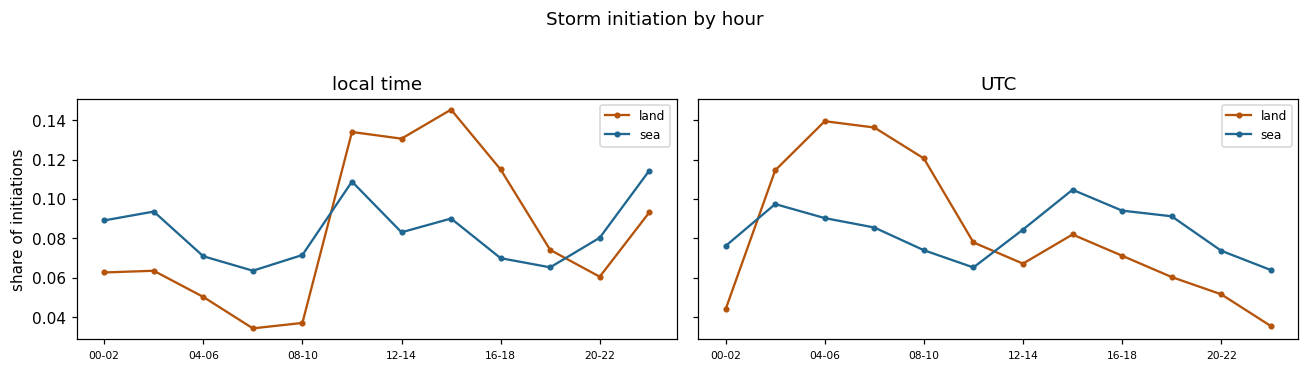

In [8]:
D = DATA_PROCESSED / "diurnal_h4.parquet"
if not D.exists():
    print("run:  python src\\diurnal.py")
else:
    t = pd.read_parquet(D)
    x = np.arange(len(t))
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
    for ax, suf, title in ((axes[0], "local", "local time"),
                           (axes[1], "utc", "UTC")):
        ax.plot(x, t[f"land_{suf}"], "o-", c="#b45309", label="land", ms=3)
        ax.plot(x, t[f"sea_{suf}"], "o-", c="#1f6690", label="sea", ms=3)
        ax.set_xticks(x[::2]); ax.set_xticklabels(t.hour[::2], fontsize=7)
        ax.set_title(title); ax.legend(fontsize=8)
    axes[0].set_ylabel("share of initiations")
    fig.suptitle("Storm initiation by hour", y=1.04); fig.tight_layout()
    pk = lambda c: t.hour[t[c].idxmax()]
    print(f"local: land peaks {pk('land_local')}, sea {pk('sea_local')}")
    print(f"UTC  : land peaks {pk('land_utc')}, sea {pk('sea_utc')}")

Land storms peak mid-afternoon, oceanic storms near midnight, and the land cycle
is more than twice as strong (4.25x against 1.80x). This is the maritime
continent's defining signal, recovered without ever being targeted, which is the
strongest independent evidence in the project that the objects are physically real.

In UTC the land peak smears because three zones are superimposed.

## 8. Sea-to-land transitions and warning lead time

```
python src\transition.py --min-volume 0.05
```

In [9]:
T = DATA_PROCESSED / "transitions_h4.parquet"
if not T.exists():
    print("run:  python src\\transition.py --min-volume 0.05")
else:
    tr = pd.read_parquet(T)
    tr["band"] = pd.cut(tr.offshore_km_at_start, [0, 15, 30, 50, 100, 1e4],
                        labels=["<15 km", "15-30", "30-50", "50-100", ">100"])
    b = tr.groupby("band", observed=True).agg(
        storms=("hours_at_sea", "size"),
        median_h=("hours_at_sea", "median"),
        p90_h=("hours_at_sea", lambda s: s.quantile(.9)))
    print(b.to_string(float_format=lambda x: f"{x:,.2f}"))
    from scipy import stats
    r, p = stats.pearsonr(tr.offshore_km_at_start, tr.hours_at_sea)
    print(f"\noffshore distance vs hours at sea: r = {r:+.3f}")

        storms  median_h  p90_h
band                           
<15 km   49399      1.00   5.50
15-30    46436      3.00   8.00
30-50    38545      5.00   9.50
50-100   25958      6.50  11.00
>100      7647      8.00  13.00



offshore distance vs hours at sea: r = +0.505


Lead time is set by **coastal geometry, not climate**. The climate region predicts
nothing at all: all three give a median 3.5 h.

Two correlations appear in this project and they are **not the same number**:

- **r = +0.505** per storm, printed by the cell above. Individual storms are noisy.
- **r = +0.877** across provinces, quoted in the README. Aggregating to a coast
  averages out per-storm noise and exposes the geometric relationship.

Both are in `docs/findings.md` Finding 53. Quote the aggregation level with the
coefficient, or the two look like a contradiction.

Riau gets 2.0 h because it faces the narrow Malacca Strait; Maluku Utara gets
5.0 h facing open ocean. A coast with no open water upwind cannot offer warning
time however often it storms.

## 9. Multi-day storm families

Age in days is not a property a storm object can have: only 3 of 12.45M last two
days, because at h=4 an object is a convective cell. It works at the **family**
level, where storms are linked within 3 h and 50 km.

The link rule has to be strict. Bounding-box overlap or a 100-200 km radius
percolates exactly as connected-component labelling did, putting 71-99% of the
month's rain in one family.

```
python src\families.py --year 2020
```

In [10]:
import glob
F = sorted(DATA_PROCESSED.glob("families_*_h4_*.parquet"))
if not F:
    print("run:  python src\\families.py --year 2020")
else:
    fam = pd.read_parquet(F[0])
    order = ["under a day", "1 day", "2 days", "3+ days"]
    a = fam.groupby("age_class").agg(families=("age_h", "size"),
                                     volume=("volume_km3", "sum"))
    a["share_families"] = a.families / a.families.sum()
    a["share_volume"] = a.volume / a.volume.sum()
    print(a.reindex([o for o in order if o in a.index])
           .to_string(float_format=lambda x: f"{x:,.4f}"))
    big = a.loc[[o for o in order[1:] if o in a.index], "share_volume"].sum()
    print(f"\nmulti-day events carry {big:.1%} of the rain")
    print(f"largest family holds {fam.volume_km3.max()/fam.volume_km3.sum():.4%} "
          "of the rain (the percolation check)")

             families      volume  share_families  share_volume
age_class                                                      
under a day    245518 17,808.3786          0.9880        0.8413
1 day            2836  2,940.2789          0.0114        0.1389
2 days            141    390.3480          0.0006        0.0184
3+ days             7     28.8790          0.0000        0.0014

multi-day events carry 15.9% of the rain
largest family holds 0.0644% of the rain (the percolation check)


## What this notebook does not establish

- **No validation.** No gauge or radar comparison. A catalogue, not a skill score.
- **No causal attribution.** The ENSO pairing in section 3 is an observation.
- **`h = 4.0` is a declared scale**, not an optimum: none exists, because the storm
  count never stabilises. Quote `h` and the segmentation method with every figure.
- **The regions are k=3 by judgement.** Silhouette prefers k=2, and nothing here has
  been compared against published Indonesian monsoon zonings.
- **Families are chains of proximity**, not tracked systems: two unrelated storms
  passing within 50 km and 3 h will join.

All 53 findings, each with the command that produced it, are in
[docs/findings.md](../docs/findings.md).